In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from keras.models import Sequential, Model
from keras.layers import LSTM, Dense, Input, Layer
from keras.losses import MeanSquaredError
from keras.metrics import RootMeanSquaredError
from keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import tensorflow.keras.backend as K
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Attention, GlobalAveragePooling1D
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

In [2]:
data = pd.read_csv("/Users/iraklisdimitriadis/Documents/Μαθήματα-Σημειώσεις Data Science/Dissertation/Processed Data/cleaned_data_csv.csv", index_col= "datetime", parse_dates= True)
data.head()

,Kwh,name,temp,feelslike,dew,humidity,precip,snow,snowdepth,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,conditions,icon
datetime,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,0.0,"Kozani, Greece",6.0,4.4,2.0,75.51,0.0,0.0,0.0,19.8,7.6,240.0,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 01:00:00,0.0,"Kozani, Greece",6.0,5.0,2.0,75.51,0.0,0.0,0.0,19.8,5.4,298.1,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 02:00:00,0.0,"Kozani, Greece",4.9,3.2,2.0,81.61,0.0,NaN,0.0,20.5,7.6,301.0,1022.4,40.9,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 03:00:00,0.0,"Kozani, Greece",4.0,4.0,1.0,80.80,0.0,NaN,0.0,20.5,3.6,294.8,1022.0,38.0,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 04:00:00,0.0,"Kozani, Greece",3.0,1.6,2.0,93.14,0.0,NaN,0.0,19.8,5.4,292.3,1021.0,41.7,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night


In [3]:
df_13_00 = data[data.index.time == pd.Timestamp('13:00:00').time()]
mean_13_00 = data[data.index.time == pd.Timestamp('13:00:00').time()]['solarradiation'].mean()

df_13_00, mean_13_00

(                        Kwh            name  temp  feelslike   dew  humidity  \
 datetime                                                                       
 2022-01-01 13:00:00  0.4263  Kozani, Greece  14.0       14.0   3.0     47.46   
 2022-01-02 13:00:00  0.4391  Kozani, Greece  14.0       14.0   1.0     41.15   
 2022-01-03 13:00:00  0.4421  Kozani, Greece  13.0       13.0   3.0     50.65   
 2022-01-04 13:00:00  0.4611  Kozani, Greece  11.0       11.0   0.0     46.61   
 2022-01-05 13:00:00  0.4397  Kozani, Greece  14.0       14.0   2.0     44.20   
 ...                     ...             ...   ...        ...   ...       ...   
 2024-06-30 13:00:00  0.6883  Kozani, Greece  31.0       29.1   7.0     22.30   
 2024-07-01 13:00:00  0.6906  Kozani, Greece  33.9       32.2  10.6     24.14   
 2024-07-02 13:00:00  0.4582  Kozani, Greece  31.0       29.5  10.0     27.32   
 2024-07-03 13:00:00  0.7472  Kozani, Greece  25.0       25.0   9.0     36.24   
 2024-07-04 13:00:00  0.6692

In [4]:
data['solarradiation'].fillna(mean_13_00, inplace=True)

In [5]:
df_picked = data[["temp", "humidity", "winddir", "solarradiation", "cloudcover", "Kwh"]]
df_picked[df_picked["solarradiation"].isna()], df_picked.iloc[-1]
print(df_picked.head(), "\n", df_picked.info(), "\n", df_picked.shape)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 21983 entries, 2022-01-01 00:00:00 to 2024-07-04 23:00:00
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   temp            21983 non-null  float64
 1   humidity        21983 non-null  float64
 2   winddir         21983 non-null  float64
 3   solarradiation  21983 non-null  float64
 4   cloudcover      21983 non-null  float64
 5   Kwh             21983 non-null  float64
dtypes: float64(6)
memory usage: 1.2 MB
                     temp  humidity  winddir  solarradiation  cloudcover  Kwh
datetime                                                                     
2022-01-01 00:00:00   6.0     75.51    240.0             0.0         0.0  0.0
2022-01-01 01:00:00   6.0     75.51    298.1             0.0         0.0  0.0
2022-01-01 02:00:00   4.9     81.61    301.0             0.0        40.9  0.0
2022-01-01 03:00:00   4.0     80.80    294.8             0.0       

In [6]:
df_picked = df_picked.dropna()
df_picked.shape

(21983, 6)

In [7]:
def df_to_x_y(df, size = 24):
    df_as_np = df.to_numpy()
    x = []
    y = []
    for i in range(len(df_as_np) - size):
        row = [a for a in df_as_np[i: i+size]]
        x.append(row)
        real_val = df_as_np[i + size][5]
        y.append(real_val)
    
    return np.array(x), np.array(y)


In [8]:
scaler = StandardScaler()
df_sacled = scaler.fit_transform(df_picked.iloc[:, :5])
df_sacled = pd.DataFrame(df_sacled)
df_sacled.tail(20)

,0,1,2,3,4
21963,0.294464,0.750458,0.824637,-0.667640,1.345699
21964,0.294464,0.531665,0.677607,-0.667640,1.345699
21965,0.408365,0.334574,0.898152,-0.667640,1.036709
21966,0.408365,0.141026,0.971668,-0.380218,1.036709
21967,0.408365,-0.041449,0.898152,-0.175998,1.036709
21968,0.522267,-0.202223,0.971668,0.357245,1.036709
21969,0.750070,-0.633608,0.971668,0.656012,1.036709
21970,0.977872,-0.868789,0.898152,2.255741,1.036709
21971,1.319577,-1.265186,0.971668,0.822414,-0.585484
21972,1.319577,-1.166419,0.751122,0.323208,-0.585484


In [9]:
df_sacled_reset = df_sacled.reset_index(drop=True)
df_picked_reset = df_picked.reset_index(drop=True)

# Concatenate the DataFrames
df_sacled = pd.concat([df_sacled_reset, df_picked_reset["Kwh"]], axis=1)


In [10]:
x_2, y_2 = df_to_x_y(df_sacled, size= 24)
x_2.shape, y_2.shape

((21959, 24, 6), (21959,))

In [11]:
x_train_2 , y_train_2 = x_2[:int(0.8*len(x_2))], y_2[: int(0.8*len(y_2))]
x_val_2, y_val_2 = x_2[int(0.8*len(x_2)): int(0.9*len(x_2))], y_2[int(0.8*len(y_2)): int(0.9*len(y_2))]
x_test_2, y_test_2 = x_2[int(0.9*len(x_2)):], y_2[int(0.9*len(y_2)):]

x_train_2.shape, y_train_2.shape, x_val_2.shape, y_val_2.shape, x_test_2.shape, y_test_2.shape

((17567, 24, 6), (17567,), (2196, 24, 6), (2196,), (2196, 24, 6), (2196,))

In [12]:
checkpoint_callback = ModelCheckpoint(
    filepath='D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras',
    monitor='val_loss',
    save_best_only=True, 
    mode='min',     
    save_weights_only=False,
    verbose=1 
)

In [13]:
input_shape = (24, 6)

inputs = Input(shape=input_shape)

lstm_out = LSTM(64, return_sequences=True)(inputs)
norm_out = BatchNormalization()(lstm_out)

query = norm_out
value = norm_out

attention_out = Attention()([query, value])
dropout_out = Dropout(0.2)(attention_out)
flattened = Dense(64, activation="relu")(dropout_out)
flattened = BatchNormalization()(flattened)
flattened = GlobalAveragePooling1D()(flattened)
outputs = Dense(1, activation="relu")(flattened)

model_1 = Model(inputs=inputs, outputs=outputs)

model_1.compile(
    loss=MeanSquaredError(),
    optimizer=Adam(learning_rate=1e-3),
    metrics=[RootMeanSquaredError()]
)

model_1.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 24, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 24, 64)    │     18,176 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 24, 64)    │        256 │ lstm[0][0]        │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 24, 64)    │          0 │ batch_normalizat… │
│ (Attention)         │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 24, 64)    │          0 │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 24, 64)    │      4,160 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 64)    │        256 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 22,913 (89.50 KB)

 Trainable params: 22,657 (88.50 KB)

 Non-trainable params: 256 (1.00 KB)

In [14]:
lr_schedule = ReduceLROnPlateau(
    monitor='loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

In [15]:
history1 = model_1.fit(x_train_2, y_train_2, 
            validation_data = (x_val_2, y_val_2), 
            epochs = 40,
            batch_size= 32,
            callbacks=[checkpoint_callback]
            )

Epoch 1/40
549/549 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0441 - root_mean_squared_error: 0.2048
Epoch 1: val_loss improved from inf to 0.02427, saving model to D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras
549/549 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0440 - root_mean_squared_error: 0.2047 - val_loss: 0.0243 - val_root_mean_squared_error: 0.1562
Epoch 2/40
543/549 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0112 - root_mean_squared_error: 0.1058
Epoch 2: val_loss improved from 0.02427 to 0.00870, saving model to D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras
549/549 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0112 - root_mean_squared_error: 0.1058 - val_loss: 0.0087 - val_root_mean_squared_error: 0.0935
Epoch 3/40
544/549 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0093 - root_mean_squared_error: 0.0963
Epoch 3: val_loss improved from 0.00870 to 0.00661, saving model to D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models

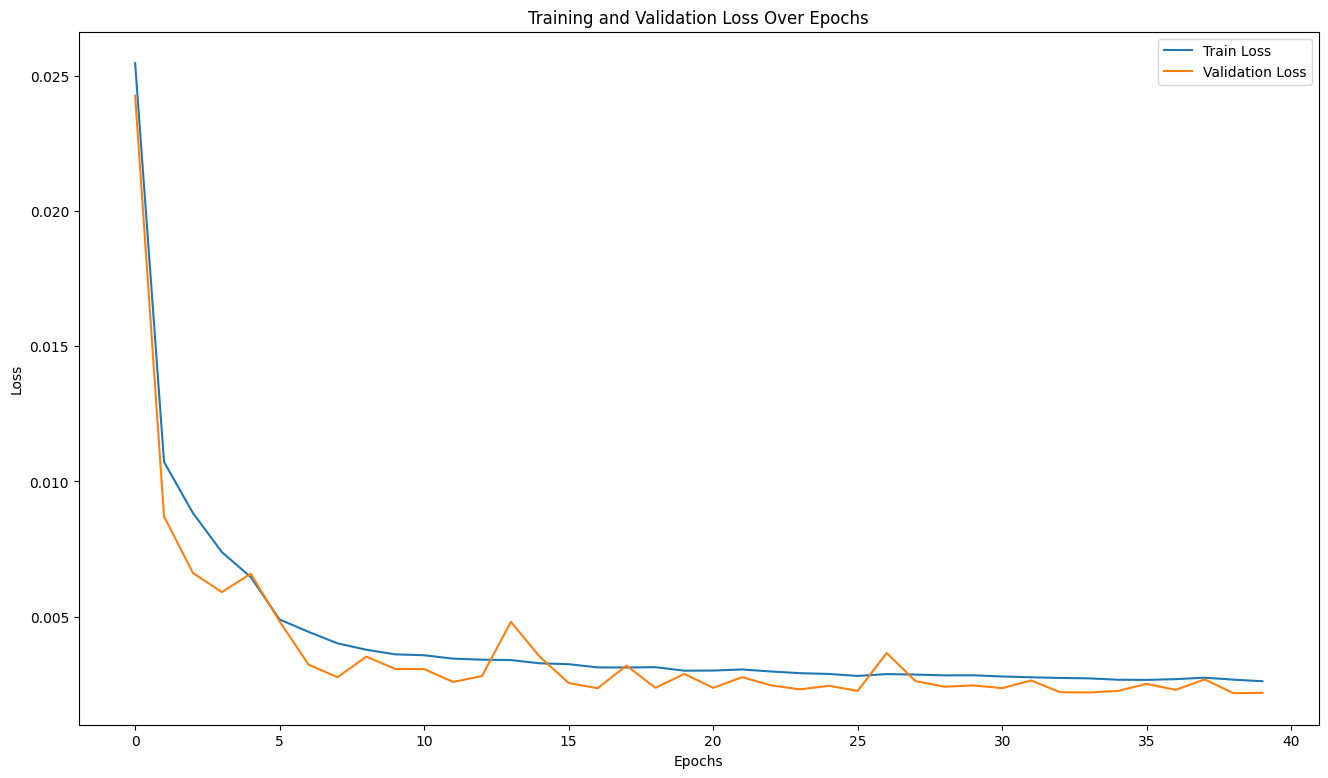

In [16]:
plt.figure(figsize = (16, 9))
plt.plot(history1.history['loss'], label='Train Loss')
plt.plot(history1.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.show()

In [17]:
test_predictions_2 = model_1.predict(x_test_2).flatten()
test_results_2 = pd.DataFrame({"Val Predictions" : test_predictions_2, "Real Data" : y_test_2})
test_results_2
test_results_2.index = df_picked.iloc[-2196:].index

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


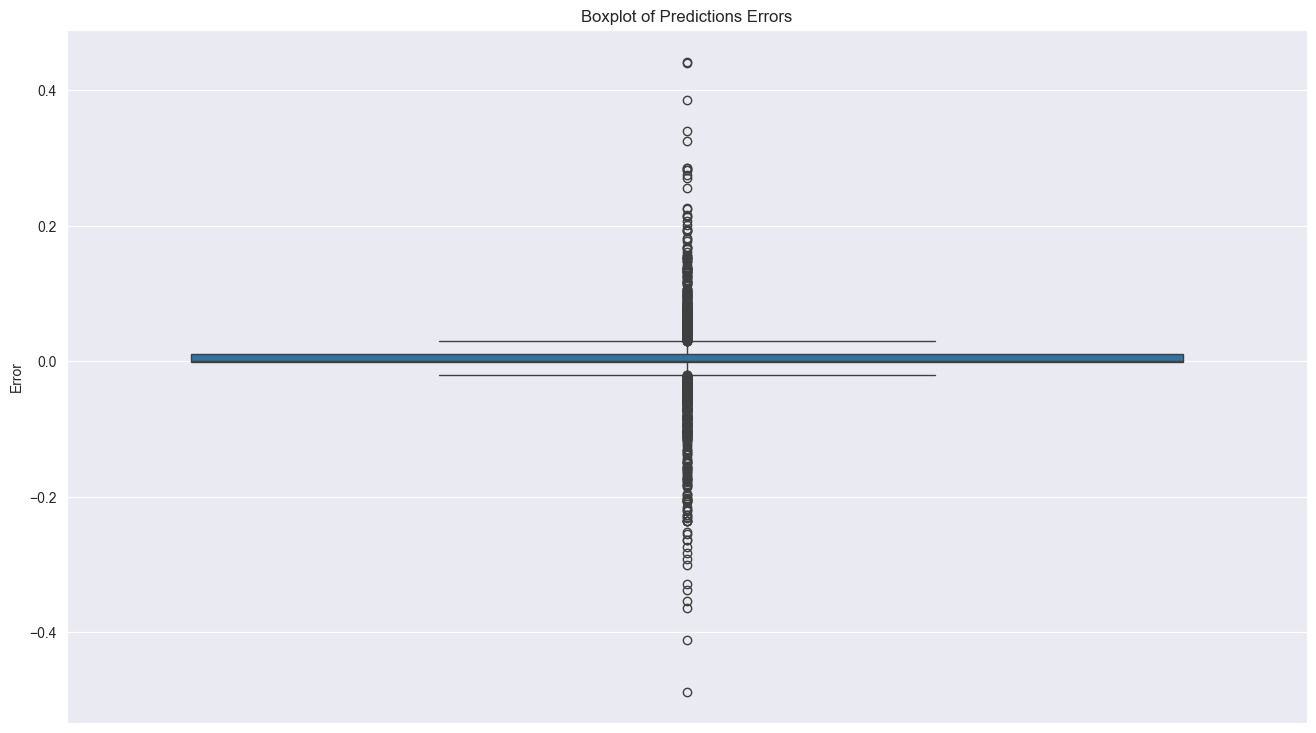

In [18]:
test_results_2['Error'] = test_results_2['Real Data'] - test_results_2['Val Predictions']

plt.figure(figsize= (16, 9))
sns.set_style('darkgrid')
sns.boxplot(y = test_results_2['Error'])
plt.title('Boxplot of Predictions Errors')
plt.show()

In [19]:
Q1 = test_results_2['Error'].quantile(0.25)
Q3 = test_results_2['Error'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 10 * IQR
upper_bound = Q3 + 10 * IQR

# Find the outliers
outliers = test_results_2[(test_results_2['Error'] < lower_bound) | (test_results_2['Error'] > upper_bound)]
print(outliers)


                     Val Predictions  Real Data     Error
datetime                                                 
2024-04-06 10:00:00         0.546607     0.3872 -0.159407
2024-04-07 08:00:00         0.191948     0.0441 -0.147848
2024-04-07 10:00:00         0.319829     0.5450  0.225171
2024-04-07 14:00:00         0.608278     0.4587 -0.149578
2024-04-12 11:00:00         0.650267     0.4449 -0.205367
...                              ...        ...       ...
2024-06-28 12:00:00         0.481513     0.6749  0.193387
2024-07-02 11:00:00         0.564731     0.3380 -0.226731
2024-07-02 16:00:00         0.323270     0.5054  0.182130
2024-07-02 17:00:00         0.348998     0.1310 -0.217998
2024-07-04 15:00:00         0.427794     0.2240 -0.203794

[126 rows x 3 columns]


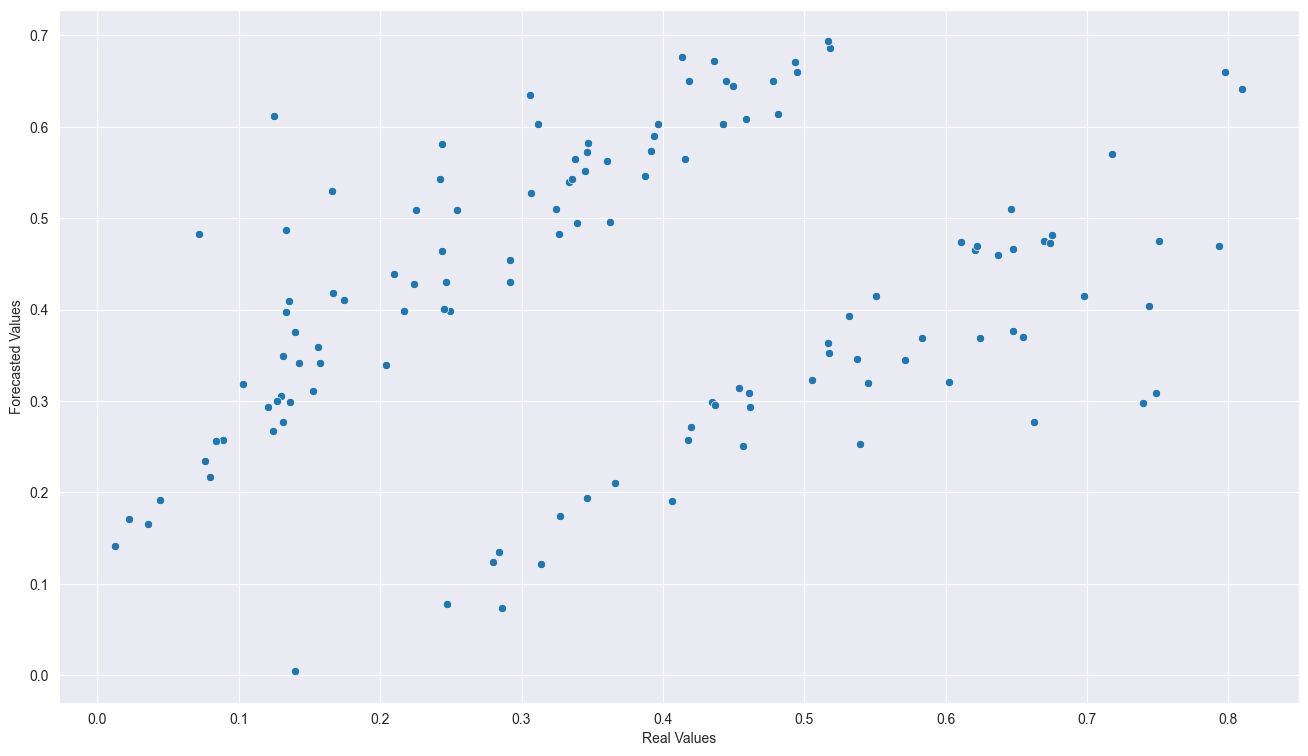

In [20]:
plt.figure(figsize= (16, 9))
sns.scatterplot(x = "Real Data", y = "Val Predictions", data = outliers)
plt.xlabel("Real Values")
plt.ylabel("Forecasted Values")
plt.show()

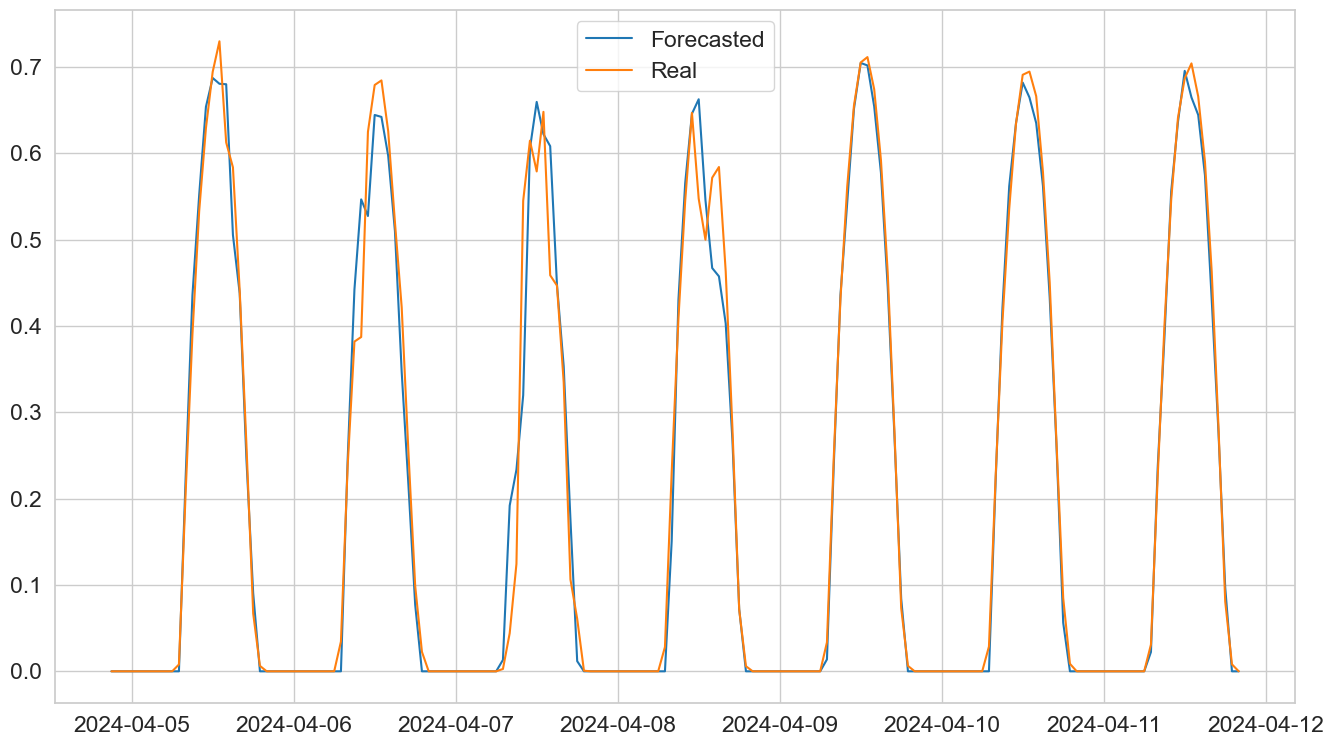

In [21]:
plt.figure(figsize= (16, 9))
sns.set_context("notebook", font_scale=1.5)
sns.set_style("whitegrid")
plt.plot(test_results_2["Val Predictions"][9:177], label = "Forecasted")
plt.plot(test_results_2["Real Data"][9:177], label = "Real")
plt.legend()
plt.show()

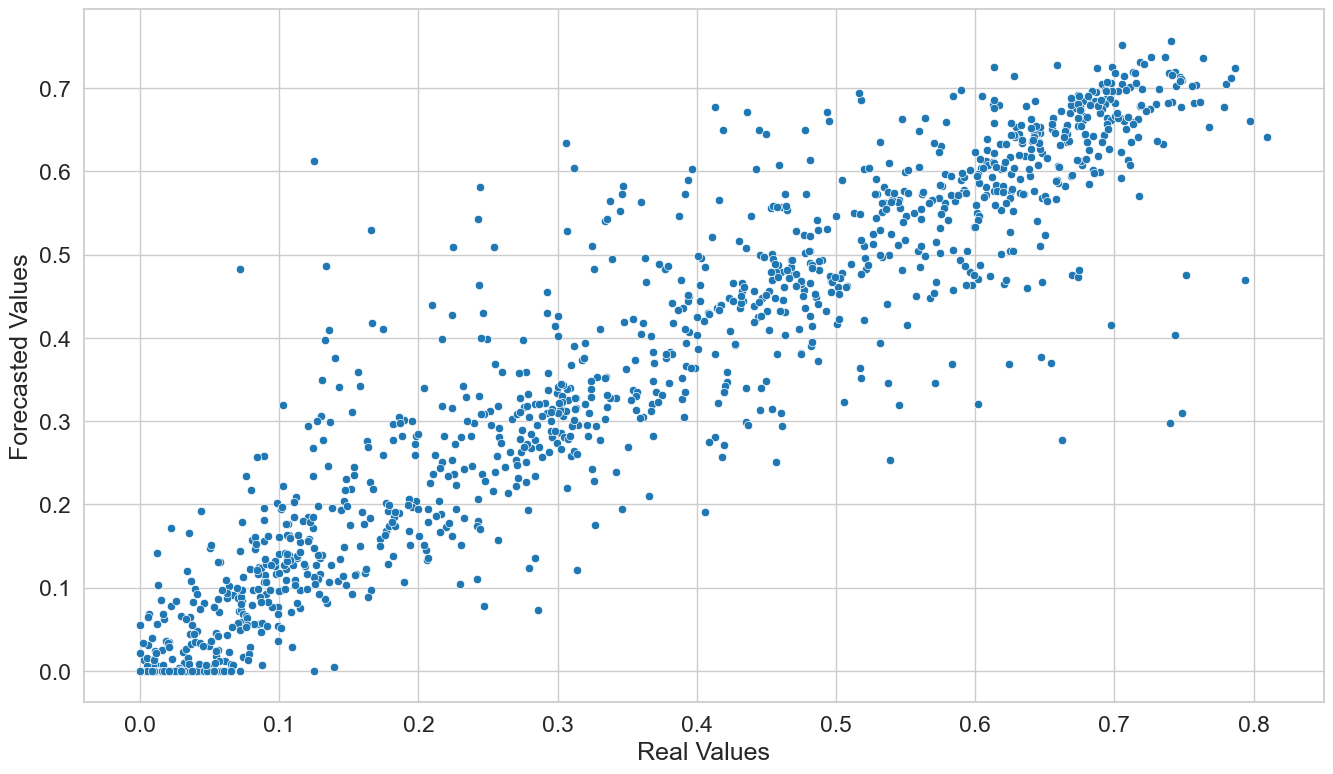

In [22]:
plt.figure(figsize= (16, 9))
sns.scatterplot(x = "Real Data", y = "Val Predictions", data = test_results_2)
plt.xlabel("Real Values")
plt.ylabel("Forecasted Values")
plt.show()

In [23]:
mse = mean_squared_error(test_results_2["Real Data"], test_results_2["Val Predictions"])
print(f" Mean Squared Error = {round(mse, 5)} \n Root Mean Squared Error = {round(np.sqrt(mse), 5)}")

ss_total = np.sum((test_results_2["Real Data"] - test_results_2["Real Data"].mean()) ** 2)
residual = np.sum((test_results_2["Real Data"] - test_results_2["Val Predictions"]) ** 2)
r_squared = 1 - (residual / ss_total)

r_squared

 Mean Squared Error = 0.00397 
 Root Mean Squared Error = 0.06297


0.9360962804052227

# 0.9385942426964701